# BUSI 1783 — Business Analytics Project
## Sustainability Reporting Evolution in UK Banking (2017–2024)
### NLP Pipeline: PDF Extraction → LDA Topic Modelling → FinBERT Sentiment → Validation


In [1]:
#INSTALL LIBRARIES  
# If any library is missing, remove the # and run this cell once.
# In Jupyter, ! runs a shell command.

!pip install pdfplumber nltk spacy gensim transformers torch pandas matplotlib seaborn scipy pyLDAvis openpyxl tqdm
!python -m spacy download en_core_web_sm

# Notes:
# - torch (PyTorch) is what FinBERT runs on.
# - pyLDAvis is only used for the interactive topic visualisation in Part 2.

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     --- ------------------------------------ 1.0/12.8 MB 34.2 MB/s eta 0:00:01
     --------------------------- ------------ 8.7/12.8 MB 36.2 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 33.5 MB/s  0:00:00
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#IMPORT LIBRARIES & CONFIGURATION
import os
import re
import glob
import warnings
from pathlib import Path

import pandas as pd
import numpy as np

warnings.filterwarnings("ignore")

BASE = Path(r"C:\Users\Thula\Documents\Sustainability_Project")

RAW_DIR       = BASE / "data" / "raw_pdfs"
PROCESSED_DIR = BASE / "data" / "processed_text"
ESG_DIR       = BASE / "data" / "esg_scores"
OUT_TABLES    = BASE / "outputs" / "tables"
OUT_FIGURES   = BASE / "outputs" / "figures"

for d in [PROCESSED_DIR, ESG_DIR, OUT_TABLES, OUT_FIGURES]:
    d.mkdir(parents=True, exist_ok=True)

# The six banks and the years we expect.
YEARS = list(range(2017, 2025))   # 2017–2024 inclusive

# AUTO-DETECT the actual folder names inside raw_pdfs
BANK_FOLDERS = [f.name for f in RAW_DIR.iterdir() if f.is_dir()]
print("Bank folders found:", BANK_FOLDERS)
print("Project base:", BASE)
print("Everything set up. Move to Cell 3.")

Bank folders found: ['Barclays', 'HSBC', 'Lloyds', 'Natwest', 'Santander', 'StandardChartered']
Project base: C:\Users\Thula\Documents\Sustainability_Project
Everything set up. Move to Cell 3.


In [3]:
# SUSTAINABILITY-SECTION KEYWORDS (Option A configuration)
# defines the keywords used to detect sustainability content pages in annual report.
# A page is kept if it contains enough sustainability-related terms. This keeps
# the sustainability NARRATIVE and drops financial-statement / governance-admin
# pages that would otherwise swamp the topic model.

SUSTAINABILITY_KEYWORDS = [
    # core ESG / climate vocabulary
    "sustainability", "sustainable", "esg", "environmental", "climate",
    "net zero", "net-zero", "carbon", "emission", "greenhouse gas", "ghg",
    "decarbonis", "decarboniz", "renewable", "biodiversity", "nature",
    "transition", "tcfd", "paris agreement", "science-based", "scope 1",
    "scope 2", "scope 3", "green finance", "green bond", "sustainable finance",
    "responsible", "stewardship",
    # social pillar
    "diversity", "inclusion", "community", "human rights", "wellbeing",
    "social impact", "financial inclusion",
    # governance-of-sustainability pillar
    "governance", "stakeholder", "materiality", "double materiality",
]

MIN_KEYWORD_HITS = 4

# For documents that are ALREADY sustainability reports (ESG report, ESG
# supplement, sustainability report/summary), we keep the WHOLE document.
# Decide which is which from the tracker's Report Title (loaded in Cell 4).
print("Sustainability keyword filter configured. Move to Cell 4.")

Sustainability keyword filter configured. Move to Cell 4.


In [4]:
# LOAD THE CORPUS TRACKER & CLASSIFY DOCUMENT TYPES

TRACKER_PATH = BASE / "corpus_tracker.xlsx"
tracker = pd.read_excel(TRACKER_PATH)

# Standardise column access (handles minor header variations)
tracker.columns = [c.strip() for c in tracker.columns]

def classify_doctype(title: str) -> str:
    """Decide if a file is a dedicated sustainability doc or a full annual report."""
    t = str(title).lower()
    if "annual report" in t and "esg" not in t and "sustainab" not in t:
        return "ANNUAL"          # full annual report -> needs section extraction
    if "assurance" in t or "reporting criteria" in t:
        return "ANNUAL"          # treat technical/assurance docs cautiously too
    # everything else = dedicated sustainability/ESG document -> keep whole file
    return "DEDICATED"

tracker["DocType"] = tracker["Report Title"].apply(classify_doctype)

print(tracker[["Bank", "Year", "Report Title", "DocType"]].to_string(index=False))
print()
print("DocType counts:", tracker["DocType"].value_counts().to_dict())
print("\nDEDICATED = whole document kept. ANNUAL = sustainability pages extracted.")
print("Move to Cell 5.")

             Bank  Year                                                                        Report Title   DocType
             HSBC  2017 Environmental, Social and Governance (ESG) Supplement Supporting sustainable growth DEDICATED
             HSBC  2018     Environmental, Social and Governance (ESG) Update Supporting sustainable growth DEDICATED
             HSBC  2019                                    Environmental, Social and Governance Update 2019 DEDICATED
             HSBC  2020                                                     Annual Report and Accounts 2020    ANNUAL
             HSBC  2021                                                     Annual Report and Accounts 2021    ANNUAL
             HSBC  2022                                                     Annual Report and Accounts 2022    ANNUAL
             HSBC  2023                                                     Annual Report and Accounts 2023    ANNUAL
             HSBC  2024                                 

In [5]:
# RESOLVE FILE PATHS FOR ALL 48 DOCUMENTS

def find_pdf(bank: str, year: int) -> Path | None:
    """Locate the PDF for a given bank/year, trying flexible folder/file names."""
    # find the folder whose name loosely matches the bank
    bank_clean = bank.lower().replace(" ", "")
    match_folder = None
    for f in RAW_DIR.iterdir():
        if f.is_dir() and f.name.lower().replace(" ", "") == bank_clean:
            match_folder = f
            break
    if match_folder is None:
        # fallback: partial match
        for f in RAW_DIR.iterdir():
            if f.is_dir() and bank_clean[:6] in f.name.lower().replace(" ", ""):
                match_folder = f
                break
    if match_folder is None:
        return None
    # try common filename patterns
    stem = f"{match_folder.name}_{year}"
    for cand in [stem + ".pdf", stem + ".PDF", stem]:
        p = match_folder / cand
        if p.exists():
            return p
    # last resort: any file in the folder containing the year
    for p in match_folder.glob(f"*{year}*"):
        if p.suffix.lower() == ".pdf":
            return p
    return None

rows = []
for _, r in tracker.iterrows():
    p = find_pdf(str(r["Bank"]), int(r["Year"]))
    rows.append({
        "bank": str(r["Bank"]),
        "year": int(r["Year"]),
        "doctype": r["DocType"],
        "title": r["Report Title"],
        "path": str(p) if p else "NOT FOUND",
        "found": p is not None,
    })
manifest = pd.DataFrame(rows)

n_found = manifest["found"].sum()
print(f"Located {n_found} / 48 PDFs.")
if n_found < 48:
    print("\nMISSING FILES — fix these before continuing:")
    print(manifest[~manifest["found"]][["bank", "year"]].to_string(index=False))
else:
    print("All 48 files located. Move to Cell 6.")

Located 48 / 48 PDFs.
All 48 files located. Move to Cell 6.


In [6]:
# EXTRACT TEXT FROM ALL PDFs
import pdfplumber
from tqdm import tqdm

# OCR is only imported if we actually need it (scanned PDFs)
def ocr_page(page):
    """OCR fallback for a scanned page. Requires pytesseract + Tesseract installed."""
    try:
        import pytesseract
        from PIL import Image
        im = page.to_image(resolution=200).original
        return pytesseract.image_to_string(im)
    except Exception as e:
        return ""  # if OCR unavailable, return empty; we log it below

def page_is_sustainability(text: str) -> bool:
    """True if a page contains enough sustainability keyword hits."""
    t = text.lower()
    hits = sum(t.count(kw) for kw in SUSTAINABILITY_KEYWORDS)
    return hits >= MIN_KEYWORD_HITS

def extract_document(path: Path, doctype: str) -> dict:
    """Extract relevant text from one PDF. Returns dict with text + diagnostics."""
    all_text = []
    kept_pages = 0
    total_pages = 0
    scanned_pages = 0
    with pdfplumber.open(path) as pdf:
        total_pages = len(pdf.pages)
        for page in pdf.pages:
            txt = page.extract_text() or ""
            if len(txt.strip()) < 30:          # likely a scanned/image page
                ocr_txt = ocr_page(page)
                if len(ocr_txt.strip()) > 30:
                    txt = ocr_txt
                    scanned_pages += 1
            if doctype == "DEDICATED":
                # keep every page — the whole document is on-topic
                all_text.append(txt)
                kept_pages += 1
            else:
                # ANNUAL report — keep only sustainability pages
                if page_is_sustainability(txt):
                    all_text.append(txt)
                    kept_pages += 1
    return {
        "text": "\n".join(all_text),
        "total_pages": total_pages,
        "kept_pages": kept_pages,
        "scanned_pages": scanned_pages,
    }

records = []
print("Extracting text from 48 documents (annual reports take longer)...\n")
for _, r in tqdm(manifest[manifest["found"]].iterrows(), total=manifest["found"].sum()):
    info = extract_document(Path(r["path"]), r["doctype"])
    # save the raw extracted text so you never have to re-extract
    out_txt = PROCESSED_DIR / f"{r['bank']}_{r['year']}.txt"
    out_txt.write_text(info["text"], encoding="utf-8")
    records.append({
        "bank": r["bank"], "year": r["year"], "doctype": r["doctype"],
        "total_pages": info["total_pages"], "kept_pages": info["kept_pages"],
        "scanned_pages": info["scanned_pages"],
        "char_count": len(info["text"]),
        "word_count": len(info["text"].split()),
    })

extract_df = pd.DataFrame(records)
extract_df.to_csv(OUT_TABLES / "extraction_summary.csv", index=False)
print("\nExtraction complete. Summary:")
print(extract_df.to_string(index=False))
print("\nSaved: outputs/tables/extraction_summary.csv")
print("Cleaned text files saved in data/processed_text/")

# QUALITY CHECK: flag any document that produced very little text
thin = extract_df[extract_df["word_count"] < 500]
if len(thin):
    print("\n⚠️  LOW-TEXT DOCUMENTS (check these — extraction may have missed content):")
    print(thin[["bank", "year", "doctype", "word_count"]].to_string(index=False))

Extracting text from 48 documents (annual reports take longer)...



 67%|██████▋   | 32/48 [352:02:05<11:45:04, 2644.02s/it]Cannot set non-stroke color: 5 components specified, but only 1 (grayscale), 3 (RGB), and 4 (CMYK) are supported
Cannot set non-stroke color: 5 components specified, but only 1 (grayscale), 3 (RGB), and 4 (CMYK) are supported
Cannot set non-stroke color: 6 components specified, but only 1 (grayscale), 3 (RGB), and 4 (CMYK) are supported
Cannot set non-stroke color: 5 components specified, but only 1 (grayscale), 3 (RGB), and 4 (CMYK) are supported
Cannot set non-stroke color: 5 components specified, but only 1 (grayscale), 3 (RGB), and 4 (CMYK) are supported
Cannot set non-stroke color: 5 components specified, but only 1 (grayscale), 3 (RGB), and 4 (CMYK) are supported
Cannot set non-stroke color: 5 components specified, but only 1 (grayscale), 3 (RGB), and 4 (CMYK) are supported
Cannot set non-stroke color: 5 components specified, but only 1 (grayscale), 3 (RGB), and 4 (CMYK) are supported
Cannot set non-stroke color: 5 component


Extraction complete. Summary:
             bank  year   doctype  total_pages  kept_pages  scanned_pages  char_count  word_count
             HSBC  2017 DEDICATED           20          20              0       66502       10072
             HSBC  2018 DEDICATED           42          42              0      129985       20063
             HSBC  2019 DEDICATED           64          64              0      263800       40708
             HSBC  2020    ANNUAL          382         127              0      707078      108102
             HSBC  2021    ANNUAL          410         155              0      881078      134768
             HSBC  2022    ANNUAL          432         171              0      980257      149135
             HSBC  2023    ANNUAL          450         175              0      978593      148575
             HSBC  2024    ANNUAL          460         163              0      921552      139656
         Barclays  2017    ANNUAL          271          34              0      156549  

In [7]:
# TEXT PRE-PROCESSING (clean, tokenise, remove stopwords, lemmatise)
import nltk
import spacy

# Download NLTK data 
for pkg in ["punkt", "punkt_tab", "stopwords"]:
    try:
        nltk.download(pkg, quiet=True)
    except Exception:
        pass

from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize

# Load spaCy model for lemmatisation (disable parser/ner for speed)
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
nlp.max_length = 5_000_000   # allow long documents

# Build a custom stopword list: standard English + banking/report boilerplate
BASE_STOP = set(stopwords.words("english"))
CUSTOM_STOP = {
    "bank", "banking", "group", "plc", "report", "annual", "year", "page",
    "company", "business", "also", "may", "within", "including", "include",
    "well", "across", "use", "used", "using", "one", "two", "three", "per",
    "cent", "percent", "million", "billion", "£", "$", "€", "table", "figure",
    "note", "notes", "see", "www", "http", "https", "com", "plc", "ltd",
    "hsbc", "barclays", "lloyds", "natwest", "santander", "standard",
    "chartered", "westminster",  # bank names themselves — remove so topics
                                  # reflect THEMES not which bank wrote them
}
STOPWORDS = BASE_STOP | CUSTOM_STOP

def clean_and_lemmatise(text: str) -> list[str]:
    """Lowercase, strip non-alpha, lemmatise, drop stopwords & short tokens."""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)     # keep letters only
    text = re.sub(r"\s+", " ", text).strip()
    doc = nlp(text)
    tokens = [
        tok.lemma_ for tok in doc
        if tok.lemma_ not in STOPWORDS
        and len(tok.lemma_) > 3            # drop very short tokens
        and not tok.is_space
    ]
    return tokens

print("Pre-processing all documents (lemmatisation can take a few minutes)...\n")
processed_docs = {}   # key: "Bank_Year" -> list of clean tokens
for _, r in tqdm(extract_df.iterrows(), total=len(extract_df)):
    raw = (PROCESSED_DIR / f"{r['bank']}_{r['year']}.txt").read_text(encoding="utf-8")
    processed_docs[f"{r['bank']}_{r['year']}"] = clean_and_lemmatise(raw)

# Save the token counts to report corpus size in Chapter 3/4
token_summary = pd.DataFrame([
    {"bank": k.rsplit("_", 1)[0], "year": int(k.rsplit("_", 1)[1]),
     "clean_tokens": len(v)}
    for k, v in processed_docs.items()
]).sort_values(["bank", "year"])
token_summary.to_csv(OUT_TABLES / "token_summary.csv", index=False)

print("\nPre-processing complete.")
print(f"Total clean tokens across corpus: {token_summary['clean_tokens'].sum():,}")
print(f"Mean tokens per document: {token_summary['clean_tokens'].mean():,.0f}")
print("Saved: outputs/tables/token_summary.csv")
print("\nMove to PART 2 (LDA + FinBERT).")

Pre-processing all documents (lemmatisation can take a few minutes)...



100%|██████████| 48/48 [09:43<00:00, 12.17s/it]


Pre-processing complete.
Total clean tokens across corpus: 1,223,122
Mean tokens per document: 25,482
Saved: outputs/tables/token_summary.csv

Move to PART 2 (LDA + FinBERT).


In [8]:

# NLP PIPELINE — PART 2: LDA, FINBERT & VALIDATION

In [9]:
# BUILD DICTIONARY & DOCUMENT-TERM MATRIX (for LDA)

from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

# Keep document order stable
doc_keys = sorted(processed_docs.keys())
texts = [processed_docs[k] for k in doc_keys]

# Build gensim dictionary and filter extreme terms
dictionary = corpora.Dictionary(texts)
# Remove terms appearing in <2 docs or >90% of docs (too rare / too common)
dictionary.filter_extremes(no_below=2, no_above=0.90)

# Bag-of-words corpus
bow_corpus = [dictionary.doc2bow(t) for t in texts]

print(f"Dictionary size after filtering: {len(dictionary)} unique terms")
print(f"Documents in corpus: {len(bow_corpus)}")
print("Move to Cell 9.")

Dictionary size after filtering: 7807 unique terms
Documents in corpus: 48
Move to Cell 9.


Testing k = 5 to 15 (this is the slowest step — a few minutes)...

  k= 5  ->  coherence c_v = 0.3859
  k= 6  ->  coherence c_v = 0.3946
  k= 7  ->  coherence c_v = 0.3823
  k= 8  ->  coherence c_v = 0.3463
  k= 9  ->  coherence c_v = 0.3812
  k=10  ->  coherence c_v = 0.3672
  k=11  ->  coherence c_v = 0.3658
  k=12  ->  coherence c_v = 0.3801
  k=13  ->  coherence c_v = 0.3866
  k=14  ->  coherence c_v = 0.3898
  k=15  ->  coherence c_v = 0.3925

>>> BEST k = 6  (coherence = 0.3946)


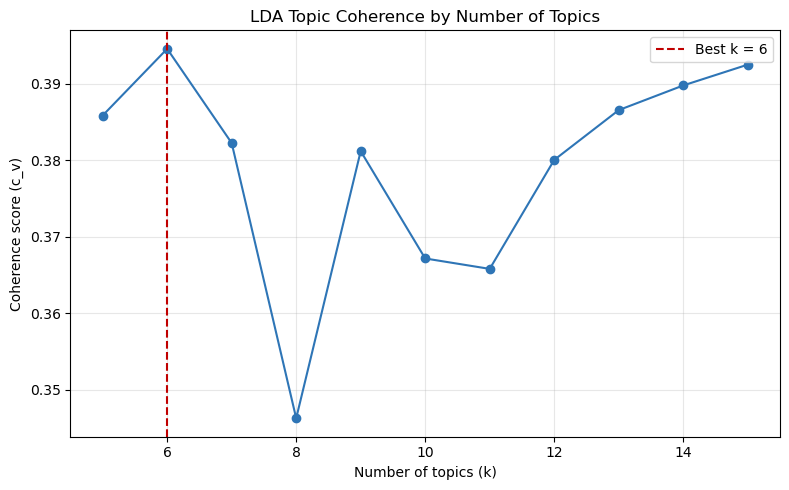

Saved: outputs/figures/coherence_by_k.png


In [10]:
# CHOOSE OPTIMAL NUMBER OF TOPICS (k) BY COHERENCE SCORE
# Tests k = 5..15 and picks the k with the highest c_v coherence.
# (Range kept modest because 48 docs is a small-to-medium corpus.)
import matplotlib.pyplot as plt

K_RANGE = range(5, 16)     # test 5 to 15 topics
coherence_scores = []

print("Testing k = 5 to 15 (this is the slowest step — a few minutes)...\n")
for k in K_RANGE:
    model = LdaModel(
        corpus=bow_corpus, id2word=dictionary, num_topics=k,
        random_state=42, passes=15, iterations=200, alpha="auto", eta="auto",
    )
    cm = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence="c_v")
    score = cm.get_coherence()
    coherence_scores.append(score)
    print(f"  k={k:2d}  ->  coherence c_v = {score:.4f}")

# Pick best k
best_idx = int(np.argmax(coherence_scores))
BEST_K = list(K_RANGE)[best_idx]
print(f"\n>>> BEST k = {BEST_K}  (coherence = {coherence_scores[best_idx]:.4f})")

# Plot coherence curve and save it (goes in your Chapter 4 / appendix)
plt.figure(figsize=(8, 5))
plt.plot(list(K_RANGE), coherence_scores, marker="o", color="#2E75B6")
plt.axvline(BEST_K, color="#C00000", linestyle="--", label=f"Best k = {BEST_K}")
plt.xlabel("Number of topics (k)")
plt.ylabel("Coherence score (c_v)")
plt.title("LDA Topic Coherence by Number of Topics")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(OUT_FIGURES / "coherence_by_k.png", dpi=300)
plt.show()
print("Saved: outputs/figures/coherence_by_k.png")

In [11]:
# TRAIN FINAL LDA MODEL & EXTRACT TOPICS
lda = LdaModel(
    corpus=bow_corpus, id2word=dictionary, num_topics=BEST_K,
    random_state=42, passes=20, iterations=400, alpha="auto", eta="auto",
)

# Print the top 15 terms per topic to assign human labels to these
print(f"\n===== {BEST_K} TOPICS (top 15 terms each) =====\n")
topic_terms = {}
for tid in range(BEST_K):
    terms = [w for w, _ in lda.show_topic(tid, topn=15)]
    topic_terms[tid] = terms
    print(f"Topic {tid}: {', '.join(terms)}\n")

# Save topics to CSV
topic_rows = [{"topic": tid, "top_terms": ", ".join(terms), "label": ""}
              for tid, terms in topic_terms.items()]
pd.DataFrame(topic_rows).to_csv(OUT_TABLES / "lda_topics.csv", index=False)
print("Saved: outputs/tables/lda_topics.csv")
print("\n>>> ACTION: open lda_topics.csv and write a short LABEL for each topic")
print("    (e.g. Topic 0 -> 'Climate Risk', Topic 1 -> 'Green Finance').")


===== 6 TOPICS (top 15 terms each) =====

Topic 0: zero, introduction, investing, bond, chain, cautionary, intensity, pathway, mtco, pcaf, evolve, exposure, coal, limitation, housing

Topic 1: supplement, holdings, entity, travel, ifrs, education, complaint, compliant, issb, sasb, unit, mortgage, banco, university, please

Topic 2: zero, home, housing, britain, overview, scottish, building, widow, chain, partner, empower, charity, mortgage, prosper, regional

Topic 3: audit, appetite, officer, remuneration, zero, exposure, holdings, monitor, oversight, loss, stress, subsidiary, chair, shareholder, could

Topic 4: barclay, home, annualreport, reputation, principal, liquidity, appetite, mortgage, stress, monitor, section, audit, oversight, nancial, treasury

Topic 5: charter, zero, audit, remuneration, exposure, income, oversight, chair, loss, intensity, appetite, shareholder, discuss, stress, monitor

Saved: outputs/tables/lda_topics.csv

>>> ACTION: open lda_topics.csv and write a sho

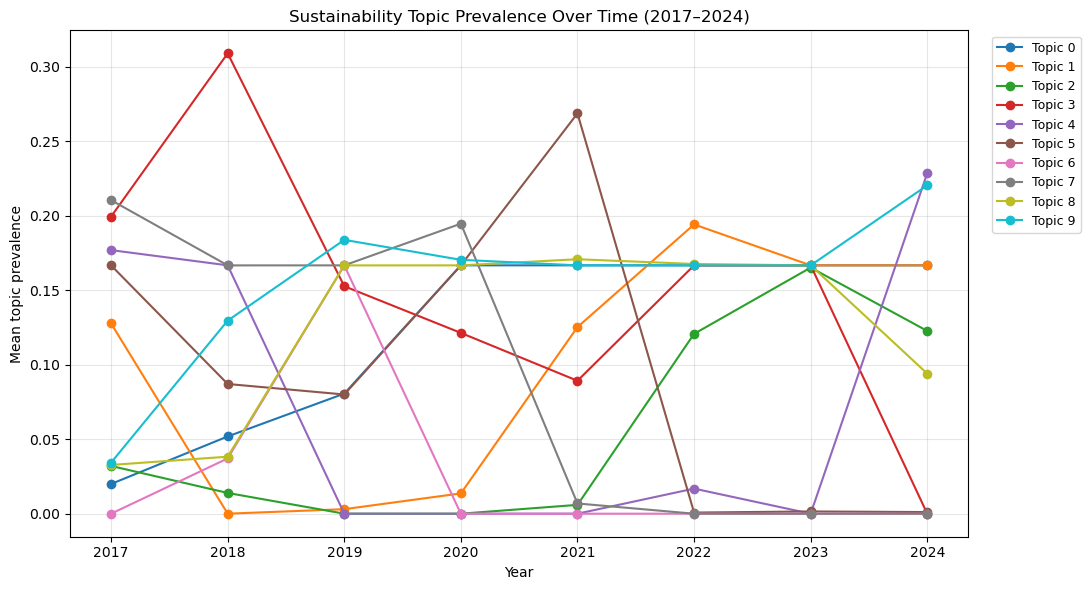

Saved: topic_prevalence_by_doc.csv, topic_prevalence_by_year.csv,
       outputs/figures/topic_prevalence_over_time.png


In [34]:
# TOPIC PREVALENCE PER DOCUMENT (AGGREGATED BY YEAR & BANK)
dist_rows = []
for key, bow in zip(doc_keys, bow_corpus):
    bank, year = key.rsplit("_", 1)
    dist = dict(lda.get_document_topics(bow, minimum_probability=0.0))
    row = {"bank": bank, "year": int(year)}
    for tid in range(BEST_K):
        row[f"topic_{tid}"] = dist.get(tid, 0.0)
    dist_rows.append(row)

prevalence = pd.DataFrame(dist_rows).sort_values(["bank", "year"])
prevalence.to_csv(OUT_TABLES / "topic_prevalence_by_doc.csv", index=False)

# Aggregate by YEAR (mean across the 6 banks) for trend analysis
topic_cols = [f"topic_{t}" for t in range(BEST_K)]
by_year = prevalence.groupby("year")[topic_cols].mean().reset_index()
by_year.to_csv(OUT_TABLES / "topic_prevalence_by_year.csv", index=False)

# Plot topic prevalence over time
plt.figure(figsize=(11, 6))
for t in range(BEST_K):
    plt.plot(by_year["year"], by_year[f"topic_{t}"], marker="o", label=f"Topic {t}")
plt.xlabel("Year"); plt.ylabel("Mean topic prevalence")
plt.title("Sustainability Topic Prevalence Over Time (2017–2024)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(OUT_FIGURES / "topic_prevalence_over_time.png", dpi=300)
plt.show()
print("Saved: topic_prevalence_by_doc.csv, topic_prevalence_by_year.csv,")
print("       outputs/figures/topic_prevalence_over_time.png")

In [35]:
# CELL 12 — INTERACTIVE TOPIC VISUALISATION (pyLDAvis)
try:
    import pyLDAvis
    import pyLDAvis.gensim_models as gensimvis
    vis = gensimvis.prepare(lda, bow_corpus, dictionary)
    pyLDAvis.save_html(vis, str(OUT_FIGURES / "lda_interactive.html"))
    print("Saved interactive topic map: outputs/figures/lda_interactive.html")
    print("(Open it in a browser; screenshot it for your report.)")
except Exception as e:
    print("pyLDAvis skipped:", e)

Saved interactive topic map: outputs/figures/lda_interactive.html
(Open it in a browser; screenshot it for your report.)


In [36]:
# FINBERT SENTIMENT ANALYSIS (document-level)
# Loads FinBERT and scores each document's overall sentiment.

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from nltk.tokenize import sent_tokenize

print("Loading FinBERT model (first run downloads ~440MB)...")
FINBERT = "ProsusAI/finbert"
tok = AutoTokenizer.from_pretrained(FINBERT)
mdl = AutoModelForSequenceClassification.from_pretrained(FINBERT)
mdl.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
mdl.to(device)
print("FinBERT loaded on:", device)

LABELS = ["positive", "negative", "neutral"]  # ProsusAI/finbert label order

def score_sentences(sentences, batch_size=16):
    """Return the mean positive/negative/neutral probability across sentences."""
    probs_all = []
    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i+batch_size]
        enc = tok(batch, return_tensors="pt", padding=True,
                  truncation=True, max_length=256).to(device)
        with torch.no_grad():
            logits = mdl(**enc).logits
        probs_all.append(torch.softmax(logits, dim=1).cpu().numpy())
    if not probs_all:
        return {"positive": float("nan"), "negative": float("nan"), "neutral": float("nan")}
    import numpy as np
    arr = np.vstack(probs_all).mean(axis=0)
    return {LABELS[j]: float(arr[j]) for j in range(3)}

# Cache each document's sentences
doc_sentences = {}
sent_rows = []
print("\nScoring DOCUMENT-level sentiment for 48 documents...\n")
for key in tqdm(doc_keys):
    bank, year = key.rsplit("_", 1)
    raw = (PROCESSED_DIR / f"{bank}_{year}.txt").read_text(encoding="utf-8")
    sents = [s.strip() for s in sent_tokenize(raw) if 20 < len(s) < 1000]
    if len(sents) > 1500:
        sents = sents[:1500]
    doc_sentences[key] = sents
    sc = score_sentences(sents)
    net = sc["positive"] - sc["negative"]
    sent_rows.append({"bank": bank, "year": int(year),
                      "pos": sc["positive"], "neg": sc["negative"],
                      "neu": sc["neutral"], "net_positivity": net,
                      "n_sentences": len(sents)})

sentiment = pd.DataFrame(sent_rows).sort_values(["bank", "year"])
sentiment.to_csv(OUT_TABLES / "finbert_sentiment.csv", index=False)
print("\nSaved: outputs/tables/finbert_sentiment.csv")
print(sentiment[["bank", "year", "net_positivity"]].to_string(index=False))

Loading FinBERT model (first run downloads ~440MB)...


C:\Users\Thula\AppData\Roaming\Python\Python313\site-packages\transformers\models\bert\tokenization_bert.py:104: DeprecationWarning: Deprecated in 0.9.0: WordPiece.__init__ will not create from files anymore, try `WordPiece.from_file` instead
  self._tokenizer = Tokenizer(WordPiece(self._vocab, unk_token=str(unk_token)))


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

FinBERT loaded on: cpu

Scoring DOCUMENT-level sentiment for 48 documents...



100%|██████████| 48/48 [3:07:34<00:00, 234.47s/it]  


Saved: outputs/tables/finbert_sentiment.csv
             bank  year  net_positivity
         Barclays  2017        0.183925
         Barclays  2018        0.064662
         Barclays  2019        0.053108
         Barclays  2020        0.164198
         Barclays  2021        0.115519
         Barclays  2022        0.128664
         Barclays  2023        0.077017
         Barclays  2024        0.064486
             HSBC  2017        0.272818
             HSBC  2018        0.254026
             HSBC  2019        0.250191
             HSBC  2020        0.243791
             HSBC  2021        0.260653
             HSBC  2022        0.265867
             HSBC  2023        0.237206
             HSBC  2024        0.239473
           Lloyds  2017        0.192514
           Lloyds  2018        0.187881
           Lloyds  2019        0.120717
           Lloyds  2020        0.251755
           Lloyds  2021        0.300418
           Lloyds  2022        0.240132
           Lloyds  2023        0.31

Computing TOPIC-LEVEL sentiment (this reuses cached sentences)...



100%|██████████| 48/48 [2:19:16<00:00, 174.10s/it]  



Mean sentiment by TOPIC (across all documents):
 topic  mean_net_positivity  total_sentences
     0             0.160224             2751
     1             0.193468             3769
     2             0.274044             3997
     3             0.179236             4575
     4             0.208155             2958
     5             0.261635             4437
     6             0.166558              586
     7             0.265715             2054
     8             0.195720             2912
     9             0.137012             2781

Saved: outputs/tables/topic_level_sentiment.csv


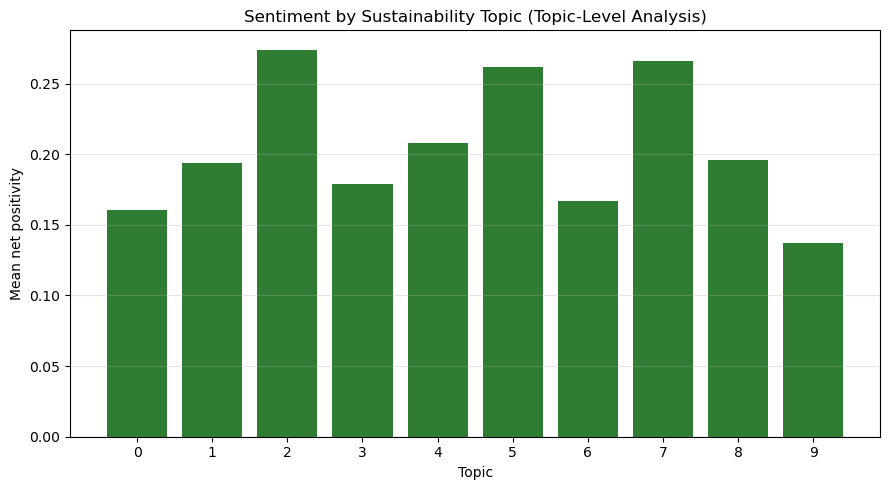

Saved: outputs/figures/sentiment_by_topic.png


In [37]:
# TOPIC-LEVEL SENTIMENT ANALYSIS
# Instead of only ONE sentiment score per document measure sentiment
# for EACH sustainability TOPIC. This links LDA + FinBERT together and gives
# far richer interpretation (e.g. "climate-risk language is more negative than
# green-finance language").
# METHOD:
#  1. For every sentence in a document, find which LDA topic it belongs to most.
#  2. Score that sentence's sentiment with FinBERT.
#  3. Average sentiment within each topic, per document, then aggregate.
import numpy as np

def dominant_topic_of_sentence(sentence):
    """Return the LDA topic id that best matches a single sentence."""
    tokens = clean_and_lemmatise(sentence)          # reuse Cell 7 cleaner
    if not tokens:
        return None
    bow = dictionary.doc2bow(tokens)
    if not bow:
        return None
    dist = lda.get_document_topics(bow, minimum_probability=0.0)
    if not dist:
        return None
    return max(dist, key=lambda x: x[1])[0]         # topic id with highest prob

topic_sent_rows = []
print("Computing TOPIC-LEVEL sentiment (this reuses cached sentences)...\n")
for key in tqdm(doc_keys):
    bank, year = key.rsplit("_", 1)
    sents = doc_sentences.get(key, [])
    # group sentences by their dominant topic
    buckets = {t: [] for t in range(BEST_K)}
    for s in sents:
        tid = dominant_topic_of_sentence(s)
        if tid is not None:
            buckets[tid].append(s)
    # score each topic bucket
    for tid, bucket in buckets.items():
        if len(bucket) == 0:
            continue
        sc = score_sentences(bucket)
        topic_sent_rows.append({
            "bank": bank, "year": int(year), "topic": tid,
            "n_sentences": len(bucket),
            "pos": sc["positive"], "neg": sc["negative"], "neu": sc["neutral"],
            "net_positivity": sc["positive"] - sc["negative"],
        })

topic_sentiment = pd.DataFrame(topic_sent_rows)
topic_sentiment.to_csv(OUT_TABLES / "topic_level_sentiment.csv", index=False)

# Aggregate: mean sentiment per topic across the whole corpus
topic_sent_summary = (topic_sentiment.groupby("topic")
                      .agg(mean_net_positivity=("net_positivity", "mean"),
                           total_sentences=("n_sentences", "sum"))
                      .reset_index())
print("\nMean sentiment by TOPIC (across all documents):")
print(topic_sent_summary.to_string(index=False))
print("\nSaved: outputs/tables/topic_level_sentiment.csv")

# Plot: average sentiment per topic
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 5))
colors = ["#2E7D32" if v >= 0 else "#C00000" for v in topic_sent_summary["mean_net_positivity"]]
plt.bar(topic_sent_summary["topic"].astype(str), topic_sent_summary["mean_net_positivity"], color=colors)
plt.axhline(0, color="grey", linewidth=0.8)
plt.xlabel("Topic"); plt.ylabel("Mean net positivity")
plt.title("Sentiment by Sustainability Topic (Topic-Level Analysis)")
plt.grid(alpha=0.3, axis="y"); plt.tight_layout()
plt.savefig(OUT_FIGURES / "sentiment_by_topic.png", dpi=300)
plt.show()
print("Saved: outputs/figures/sentiment_by_topic.png")

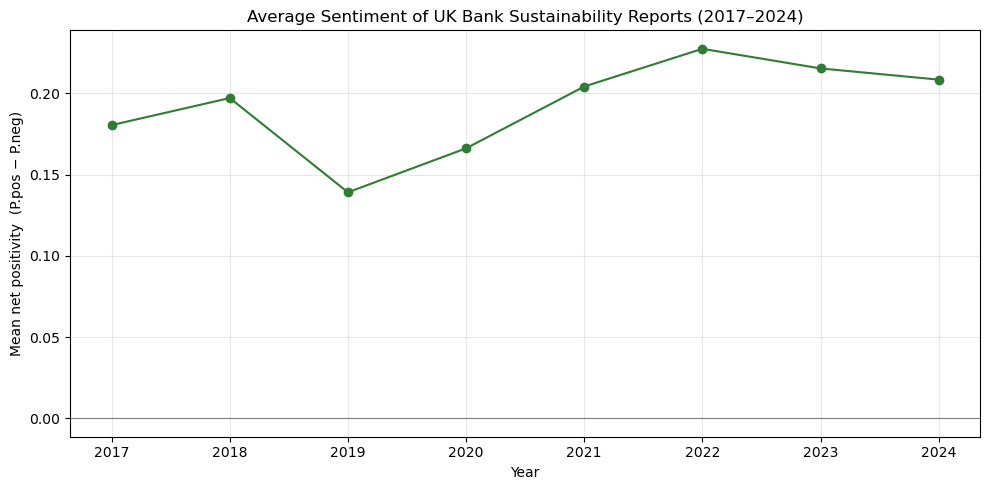

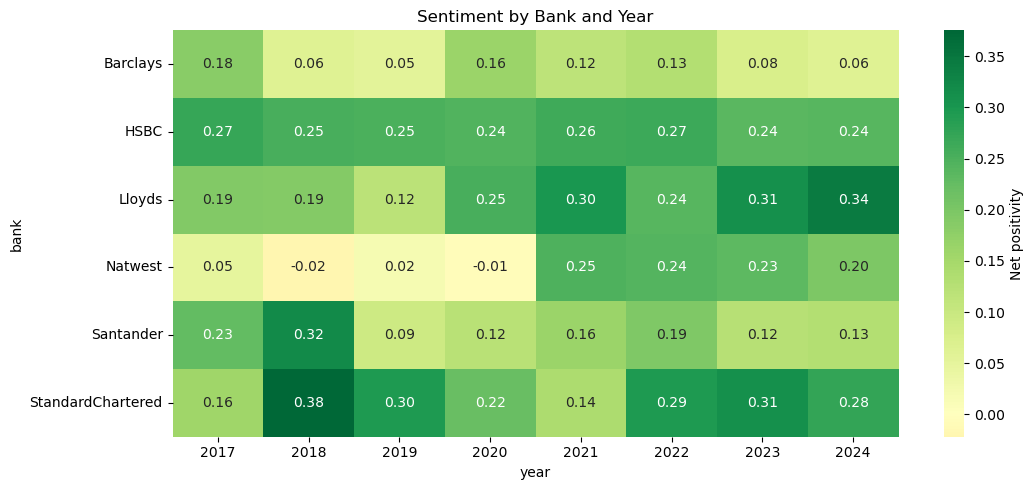

Saved: sentiment_over_time.png, sentiment_heatmap.png


In [38]:
# SENTIMENT TRENDS: PLOTS

import seaborn as sns

# Mean net positivity per year
sent_year = sentiment.groupby("year")["net_positivity"].mean().reset_index()
plt.figure(figsize=(10, 5))
plt.plot(sent_year["year"], sent_year["net_positivity"], marker="o", color="#2E7D32")
plt.axhline(0, color="grey", linewidth=0.8)
plt.xlabel("Year"); plt.ylabel("Mean net positivity  (P.pos − P.neg)")
plt.title("Average Sentiment of UK Bank Sustainability Reports (2017–2024)")
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(OUT_FIGURES / "sentiment_over_time.png", dpi=300)
plt.show()

# Heatmap: bank x year net positivity
pivot = sentiment.pivot(index="bank", columns="year", values="net_positivity")
plt.figure(figsize=(11, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            cbar_kws={"label": "Net positivity"})
plt.title("Sentiment by Bank and Year")
plt.tight_layout()
plt.savefig(OUT_FIGURES / "sentiment_heatmap.png", dpi=300)
plt.show()
print("Saved: sentiment_over_time.png, sentiment_heatmap.png")

PANEL-LEVEL validation on 48 bank-year observations (n=48).

  Net positivity vs env_score:  rho = -0.329,  p = 0.1003  (n=26, not significant)
  Net positivity vs gov_score:  rho = 0.151,  p = 0.4618  (n=26, not significant)

Per-bank DESCRIPTIVE summary (no per-bank correlation — n too small):
             bank  mean_net_positivity  mean_env  mean_gov
         Barclays             0.106447     93.20     85.00
             HSBC             0.253003     86.75     75.50
           Lloyds             0.243373     91.40     86.00
          Natwest             0.119953     76.00     81.25
        Santander             0.171933     94.50     82.25
StandardChartered             0.258867     79.75     89.75


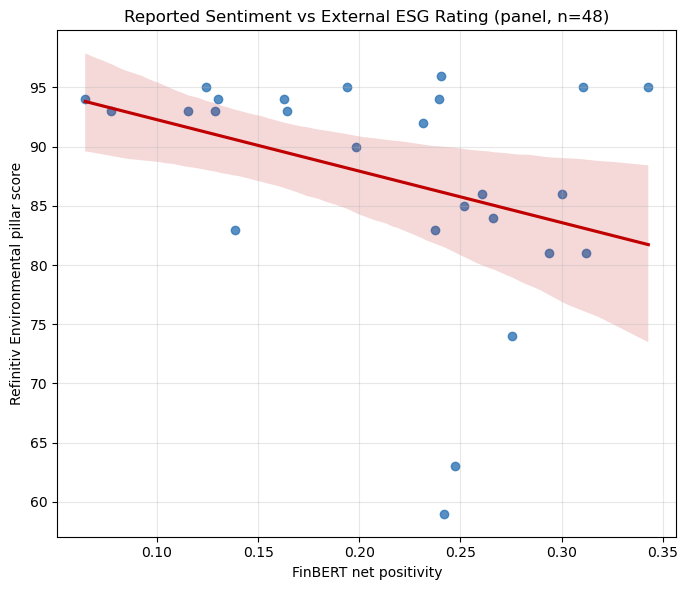


Saved: validation_panel_spearman.csv, bank_descriptive_summary.csv,
       sentiment_vs_esg_merged.csv, outputs/figures/sentiment_vs_esg.png


In [39]:
# VALIDATION: SPEARMAN CORRELATION (PANEL-LEVEL)

# PREREQUISITE: data/esg_scores/eikon_esg_scores.csv with columns bank, year, env_score, gov_score
from scipy.stats import spearmanr

esg_path = ESG_DIR / "eikon_esg_scores.csv"
if not esg_path.exists():
    print("eikon_esg_scores.csv NOT found.")
    print("Create it with columns: bank, year, env_score, gov_score  (48 rows)")
    print("Then re-run this cell.")
else:
    esg = pd.read_csv(esg_path)
    merged = sentiment.merge(esg, on=["bank", "year"], how="inner")
    print(f"PANEL-LEVEL validation on {len(merged)} bank-year observations (n={len(merged)}).\n")

    results = []
    for pillar in ["env_score", "gov_score"]:
        valid = merged.dropna(subset=["net_positivity", pillar])
        rho, p = spearmanr(valid["net_positivity"], valid[pillar])
        results.append({"pillar": pillar, "spearman_rho": round(rho, 3),
                        "p_value": round(p, 4), "n": len(valid)})
        sig = "significant" if p < 0.05 else "not significant"
        print(f"  Net positivity vs {pillar}:  rho = {rho:.3f},  p = {p:.4f}  (n={len(valid)}, {sig})")

    pd.DataFrame(results).to_csv(OUT_TABLES / "validation_panel_spearman.csv", index=False)

    # OPTIONAL descriptive-only view: mean positivity vs mean ESG per bank
    # (This is DESCRIPTIVE, not inferential — no correlation computed per bank.)
    bank_desc = (merged.groupby("bank")
                 .agg(mean_net_positivity=("net_positivity", "mean"),
                      mean_env=("env_score", "mean"),
                      mean_gov=("gov_score", "mean"))
                 .reset_index())
    bank_desc.to_csv(OUT_TABLES / "bank_descriptive_summary.csv", index=False)
    print("\nPer-bank DESCRIPTIVE summary (no per-bank correlation — n too small):")
    print(bank_desc.to_string(index=False))

    # Scatter (panel-level) for the Environmental pillar
    import seaborn as sns
    plt.figure(figsize=(7, 6))
    sns.regplot(data=merged, x="net_positivity", y="env_score",
                scatter_kws={"color": "#2E75B6"}, line_kws={"color": "#C00000"})
    plt.xlabel("FinBERT net positivity"); plt.ylabel("Refinitiv Environmental pillar score")
    plt.title(f"Reported Sentiment vs External ESG Rating (panel, n={len(merged)})")
    plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig(OUT_FIGURES / "sentiment_vs_esg.png", dpi=300)
    plt.show()

    merged.to_csv(OUT_TABLES / "sentiment_vs_esg_merged.csv", index=False)
    print("\nSaved: validation_panel_spearman.csv, bank_descriptive_summary.csv,")
    print("       sentiment_vs_esg_merged.csv, outputs/figures/sentiment_vs_esg.png")

In [40]:
# EXPORT A SINGLE SUMMARY WORKBOOK FOR SENDING TO CLAUDE

summary_path = OUT_TABLES / "RESULTS_FOR_CHAPTER4.xlsx"
with pd.ExcelWriter(summary_path, engine="openpyxl") as xw:
    token_summary.to_excel(xw, sheet_name="corpus_size", index=False)
    pd.DataFrame(topic_rows).to_excel(xw, sheet_name="lda_topics", index=False)
    by_year.to_excel(xw, sheet_name="topic_prevalence_year", index=False)
    prevalence.to_excel(xw, sheet_name="topic_prevalence_doc", index=False)
    sentiment.to_excel(xw, sheet_name="sentiment", index=False)
    topic_sentiment.to_excel(xw, sheet_name="topic_level_sentiment", index=False)
    topic_sent_summary.to_excel(xw, sheet_name="sentiment_by_topic", index=False)
    pd.DataFrame({"k_tested": list(K_RANGE),
                  "coherence": coherence_scores}).to_excel(
                  xw, sheet_name="coherence", index=False)
    if esg_path.exists():
        merged.to_excel(xw, sheet_name="sentiment_vs_esg", index=False)
        pd.DataFrame(results).to_excel(xw, sheet_name="validation_panel", index=False)
        bank_desc.to_excel(xw, sheet_name="bank_descriptive", index=False)

print(f"\n✅ ALL DONE. Master results file saved:\n   {summary_path}")
print("\nSend me RESULTS_FOR_CHAPTER4.xlsx (plus your topic labels) and we'll")
print("write Chapter 4 around your real findings.")


✅ ALL DONE. Master results file saved:
   C:\Users\Thula\Documents\Sustainability_Project\outputs\tables\RESULTS_FOR_CHAPTER4.xlsx

Send me RESULTS_FOR_CHAPTER4.xlsx (plus your topic labels) and we'll
write Chapter 4 around your real findings.


Extracted 21963 words at threshold 3
Saved re-extracted file: C:\Users\Thula\Documents\Sustainability_Project\data\processed_text\StandardChartered_2021.txt


100%|██████████| 48/48 [16:59<00:00, 21.23s/it]



Token counts after stronger cleaning:
             bank  year  clean_tokens
         Barclays  2017          9482
         Barclays  2018          5065
         Barclays  2019          8732
         Barclays  2020         10659
         Barclays  2021         13543
         Barclays  2022         17297
         Barclays  2023         18425
         Barclays  2024         19499
             HSBC  2017          4552
             HSBC  2018          8742
             HSBC  2019         17708
             HSBC  2020         44526
             HSBC  2021         55573
             HSBC  2022         62394
             HSBC  2023         61867
             HSBC  2024         58301
           Lloyds  2017         23455
           Lloyds  2018         28164
           Lloyds  2019          2627
           Lloyds  2020         23354
           Lloyds  2021         19006
           Lloyds  2022         21034
           Lloyds  2023         45339
           Lloyds  2024         47980
          N

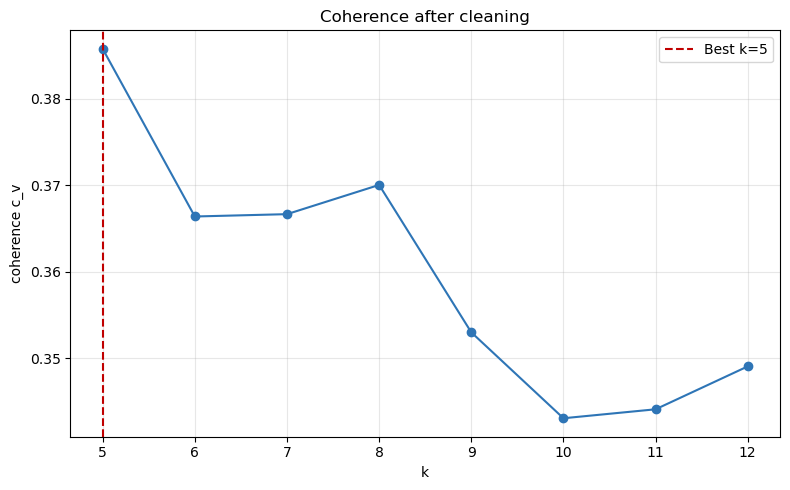


===== 5 TOPICS after cleaning =====

Topic 0: hong_kong, intensity, sustainability_aspiration, futuremaker, ccib, singapore, cpbb, effectiveness_review, adaptation, collateral, supplementary_information, venture, asia, ermf, global_head

Topic 1: hong_kong, thermal_coal, covid, asia, transition_zero, wholesale, power_utility, cash_flow, covid_pandemic, ibor, datum_privacy, cybersecurity, covid_outbreak, singapore, noel_quinn

Topic 2: sustainable_future, strategy_inclusive, transition_zero, future_community, inclusive_zero, social_housing, retrofit, food, aviation, automotive, farm, protect_nature, economic_crime, thermal_coal, electric

Topic 3: metric_target, important_information, enterprise_learn, purpose_lead, principle_responsible, coutt, ethnic_minority, responsible_investing, funding_financing, breakthrough, customer_satisfaction, green_social, green_bond, coutts, natw

Topic 4: datum_criterion, libor, mortgage_portfolio, responsible_investing, total_number, ermf, supplement_m

In [29]:

import pdfplumber

def extract_with_threshold(path, min_hits):
    """Extract sustainability pages using a custom (lower) keyword threshold."""
    kept = []
    with pdfplumber.open(path) as pdf:
        for page in pdf.pages:
            txt = page.extract_text() or ""
            t = txt.lower()
            hits = sum(t.count(kw) for kw in SUSTAINABILITY_KEYWORDS)
            if hits >= min_hits:
                kept.append(txt)
    return "\n".join(kept)

# locate the Std Chartered 2021 file
sc_path = None
for f in RAW_DIR.iterdir():
    if f.is_dir() and "chart" in f.name.lower():
        for p in f.glob("*2021*"):
            if p.suffix.lower() == ".pdf":
                sc_path = p
if sc_path is None:
    print("Could not find Standard Chartered 2021 PDF — check the filename.")
else:
    # try progressively lower thresholds until we get real content
    for thr in [3, 2, 1]:
        text = extract_with_threshold(sc_path, thr)
        if len(text.split()) > 500:
            print(f"Extracted {len(text.split())} words at threshold {thr}")
            out = PROCESSED_DIR / "StandardChartered_2021.txt"
            out.write_text(text, encoding="utf-8")
            print("Saved re-extracted file:", out)
            break
    else:
        print("Still low text even at threshold 1 — this PDF may be scanned.")
        print("If so, we need OCR, or swap in the 2021 Sustainability Summary.")


# Pre-processing WITH STRONGER CLEANING
#  Removes bank names, report boilerplate, governance-admin vocab, and
#   OCR fragments that were polluting the topics.

import nltk, spacy, re
from nltk.corpus import stopwords

for pkg in ["punkt", "punkt_tab", "stopwords"]:
    try: nltk.download(pkg, quiet=True)
    except Exception: pass

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
nlp.max_length = 5_000_000

BASE_STOP = set(stopwords.words("english"))

# --- MUCH bigger custom stoplist ---
CUSTOM_STOP = {
    # generic report boilerplate
    "bank","banking","group","plc","report","annual","annualreport","year","page",
    "company","business","also","may","within","including","include","well","across",
    "use","used","using","one","two","three","per","cent","percent","million","billion",
    "table","figure","note","see","www","http","https","com","ltd","please","overview",
    "introduction","section","approach","continue","provide","across","key","new","make",
    "made","set","work","help","support","ensure","deliver","drive","enable","build",
    # bank names & brand fragments (STOP topics clustering by bank)
    "hsbc","barclays","barclay","lloyds","lloyd","natwest","westminster","santander",
    "banco","standard","chartered","charter","holdings","subsidiary","widow","scottish",
    "britain","british","britannia",
    # financial-statement / governance-admin vocabulary (not sustainability themes)
    "audit","auditor","remuneration","director","board","committee","officer","chair",
    "chairman","shareholder","oversight","monitor","appetite","liquidity","treasury",
    "capital","asset","income","loss","stress","exposure","principal","reputation",
    "compliance","complaint","compliant","entity","unit","ifrs","issb","sasb","pcaf",
    "disclosure","statement","framework","policy","governance","risk","management",
    "material","materiality","stakeholder","regulatory","regulation","requirement",
    # OCR / tokenisation fragments seen in the output
    "nancial","cative","cautionary","mtco","evolve","could","discuss","please",
}
STOPWORDS = BASE_STOP | CUSTOM_STOP
# --- Path B: extra noise removal (geography, brand, admin fragments) ---
EXTRA_STOP = {
    # geography & brand names
    "hong","kong","hong_kong","singapore","asia","asian","britain",
    "futuremaker","ccib","cpbb","ermf","coutts","coutt","natw","noel",
    "quinn","noel_quinn","banco","scottish","widow",
    # financial / admin fragments
    "libor","cash_flow","reference_rate","collateral","legal_function",
    "consumer_duty","datum_criterion","datum_privacy","effectiveness_review",
    "important_information","supplementary_information","supplement_methodology",
    "total_number","wholesale","adverse_effect","exist_emerge","scope_method",
    "reference","criterion","methodology","aspiration","venture",
    "global_head","enterprise_learn","principle_responsible",
}
STOPWORDS = STOPWORDS | EXTRA_STOP

def clean_and_lemmatise(text: str) -> list[str]:
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    doc = nlp(text)
    return [tok.lemma_ for tok in doc
            if tok.lemma_ not in STOPWORDS
            and len(tok.lemma_) > 3
            and not tok.is_space]

from tqdm import tqdm
processed_docs = {}
for key in tqdm([f"{r.bank}_{r.year}" for r in extract_df.itertuples()]):
    fp = PROCESSED_DIR / f"{key}.txt"
    if fp.exists():
        raw = fp.read_text(encoding="utf-8")
        processed_docs[key] = clean_and_lemmatise(raw)
    else:
        processed_docs[key] = []

token_summary = pd.DataFrame([
    {"bank": k.rsplit("_",1)[0], "year": int(k.rsplit("_",1)[1]), "clean_tokens": len(v)}
    for k,v in processed_docs.items()]).sort_values(["bank","year"])
print("\nToken counts after stronger cleaning:")
print(token_summary.to_string(index=False))
print(f"\nTotal tokens: {token_summary['clean_tokens'].sum():,}")
print("Any zero-token docs?", (token_summary['clean_tokens']==0).sum())


# ADD BIGRAMS, STRICTER FILTER, RETUNE k
#   Bigrams capture "net_zero", "green_bond", "climate_risk" as single themes.

from gensim import corpora
from gensim.models import LdaModel, CoherenceModel, Phrases
from gensim.models.phrases import Phraser
import numpy as np, matplotlib.pyplot as plt

doc_keys = sorted(processed_docs.keys())
texts = [processed_docs[k] for k in doc_keys]

# Build bigrams (e.g. "net"+"zero" -> "net_zero")
phrases = Phrases(texts, min_count=5, threshold=10)
bigram = Phraser(phrases)
texts = [bigram[t] for t in texts]

dictionary = corpora.Dictionary(texts)
# stricter filtering: drop terms in <3 docs or >50% of docs (removes generic terms)
dictionary.filter_extremes(no_below=3, no_above=0.5)
bow_corpus = [dictionary.doc2bow(t) for t in texts]
print(f"Dictionary size: {len(dictionary)} terms after stricter filtering")

# Re-test k with the cleaned data
K_RANGE = range(5, 13)
coherence_scores = []
print("\nRe-testing k with cleaned corpus...\n")
for k in K_RANGE:
    m = LdaModel(corpus=bow_corpus, id2word=dictionary, num_topics=k,
                 random_state=42, passes=15, iterations=200, alpha="auto", eta="auto")
    cm = CoherenceModel(model=m, texts=texts, dictionary=dictionary, coherence="c_v")
    sc = cm.get_coherence(); coherence_scores.append(sc)
    print(f"  k={k:2d} -> c_v = {sc:.4f}")

BEST_K = list(K_RANGE)[int(np.argmax(coherence_scores))]
print(f"\n>>> BEST k = {BEST_K} (coherence {max(coherence_scores):.4f})")

plt.figure(figsize=(8,5))
plt.plot(list(K_RANGE), coherence_scores, marker="o", color="#2E75B6")
plt.axvline(BEST_K, color="#C00000", linestyle="--", label=f"Best k={BEST_K}")
plt.xlabel("k"); plt.ylabel("coherence c_v"); plt.legend(); plt.grid(alpha=0.3)
plt.title("Coherence after cleaning"); plt.tight_layout()
plt.savefig(OUT_FIGURES / "coherence_by_k.png", dpi=300); plt.show()


# REPLACES CELL 10 : train final model, inspect topics

lda = LdaModel(corpus=bow_corpus, id2word=dictionary, num_topics=BEST_K,
               random_state=42, passes=25, iterations=400, alpha="auto", eta="auto")

print(f"\n===== {BEST_K} TOPICS after cleaning =====\n")
topic_rows = []
for tid in range(BEST_K):
    terms = [w for w,_ in lda.show_topic(tid, topn=15)]
    topic_rows.append({"topic": tid, "top_terms": ", ".join(terms), "label": ""})
    print(f"Topic {tid}: {', '.join(terms)}\n")

pd.DataFrame(topic_rows).to_csv(OUT_TABLES / "lda_topics.csv", index=False)
print(">>> Check these topics. They should now reflect THEMES, not bank names.")
print(">>> If still noisy, tell Claude the new topic terms and we tune further.")
print(">>> If they look thematic, assign labels and re-run Cells 11–16.")

In [30]:
# (pre-processing) WITH STRONGER CLEANING (Replacement)
#   Removes bank names, report boilerplate, governance-admin vocab, and
#   OCR fragments that were polluting the topics.

import nltk, spacy, re
from nltk.corpus import stopwords

for pkg in ["punkt", "punkt_tab", "stopwords"]:
    try: nltk.download(pkg, quiet=True)
    except Exception: pass

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
nlp.max_length = 5_000_000

BASE_STOP = set(stopwords.words("english"))

# --- MUCH bigger custom stoplist ---
CUSTOM_STOP = {
    # generic report boilerplate
    "bank","banking","group","plc","report","annual","annualreport","year","page",
    "company","business","also","may","within","including","include","well","across",
    "use","used","using","one","two","three","per","cent","percent","million","billion",
    "table","figure","note","see","www","http","https","com","ltd","please","overview",
    "introduction","section","approach","continue","provide","across","key","new","make",
    "made","set","work","help","support","ensure","deliver","drive","enable","build",
    # bank names & brand fragments (STOP topics clustering by bank)
    "hsbc","barclays","barclay","lloyds","lloyd","natwest","westminster","santander",
    "banco","standard","chartered","charter","holdings","subsidiary","widow","scottish",
    "britain","british","britannia",
    # financial-statement / governance-admin vocabulary (not sustainability themes)
    "audit","auditor","remuneration","director","board","committee","officer","chair",
    "chairman","shareholder","oversight","monitor","appetite","liquidity","treasury",
    "capital","asset","income","loss","stress","exposure","principal","reputation",
    "compliance","complaint","compliant","entity","unit","ifrs","issb","sasb","pcaf",
    "disclosure","statement","framework","policy","governance","risk","management",
    "material","materiality","stakeholder","regulatory","regulation","requirement",
    # OCR / tokenisation fragments seen in your output
    "nancial","cative","cautionary","mtco","evolve","could","discuss","please",
}
STOPWORDS = BASE_STOP | CUSTOM_STOP
# --- Path B: extra noise removal (geography, brand, admin fragments) ---
EXTRA_STOP = {
    # geography & brand names
    "hong","kong","hong_kong","singapore","asia","asian","britain",
    "futuremaker","ccib","cpbb","ermf","coutts","coutt","natw","noel",
    "quinn","noel_quinn","banco","scottish","widow",
    # financial / admin fragments
    "libor","cash_flow","reference_rate","collateral","legal_function",
    "consumer_duty","datum_criterion","datum_privacy","effectiveness_review",
    "important_information","supplementary_information","supplement_methodology",
    "total_number","wholesale","adverse_effect","exist_emerge","scope_method",
    "reference","criterion","methodology","aspiration","venture",
    "global_head","enterprise_learn","principle_responsible",
}
STOPWORDS = STOPWORDS | EXTRA_STOP

def clean_and_lemmatise(text: str) -> list[str]:
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    doc = nlp(text)
    return [tok.lemma_ for tok in doc
            if tok.lemma_ not in STOPWORDS
            and len(tok.lemma_) > 3
            and not tok.is_space]

from tqdm import tqdm
processed_docs = {}
for key in tqdm([f"{r.bank}_{r.year}" for r in extract_df.itertuples()]):
    fp = PROCESSED_DIR / f"{key}.txt"
    if fp.exists():
        raw = fp.read_text(encoding="utf-8")
        processed_docs[key] = clean_and_lemmatise(raw)
    else:
        processed_docs[key] = []

token_summary = pd.DataFrame([
    {"bank": k.rsplit("_",1)[0], "year": int(k.rsplit("_",1)[1]), "clean_tokens": len(v)}
    for k,v in processed_docs.items()]).sort_values(["bank","year"])
print("\nToken counts after stronger cleaning:")
print(token_summary.to_string(index=False))
print(f"\nTotal tokens: {token_summary['clean_tokens'].sum():,}")
print("Any zero-token docs?", (token_summary['clean_tokens']==0).sum())


100%|██████████| 48/48 [17:14<00:00, 21.54s/it]


Token counts after stronger cleaning:
             bank  year  clean_tokens
         Barclays  2017          9445
         Barclays  2018          5041
         Barclays  2019          8662
         Barclays  2020         10572
         Barclays  2021         13406
         Barclays  2022         17140
         Barclays  2023         18341
         Barclays  2024         19422
             HSBC  2017          4513
             HSBC  2018          8681
             HSBC  2019         17495
             HSBC  2020         44077
             HSBC  2021         54961
             HSBC  2022         61775
             HSBC  2023         61217
             HSBC  2024         57707
           Lloyds  2017         23355
           Lloyds  2018         28048
           Lloyds  2019          2622
           Lloyds  2020         23239
           Lloyds  2021         18961
           Lloyds  2022         20930
           Lloyds  2023         45212
           Lloyds  2024         47856
          N

Dictionary size: 9333 terms after stricter filtering

Re-testing k with cleaned corpus...

  k= 5 -> c_v = 0.3635
  k= 6 -> c_v = 0.3674
  k= 7 -> c_v = 0.3531
  k= 8 -> c_v = 0.3759
  k= 9 -> c_v = 0.3619
  k=10 -> c_v = 0.3852
  k=11 -> c_v = 0.3465
  k=12 -> c_v = 0.3766

>>> BEST k = 10 (coherence 0.3852)


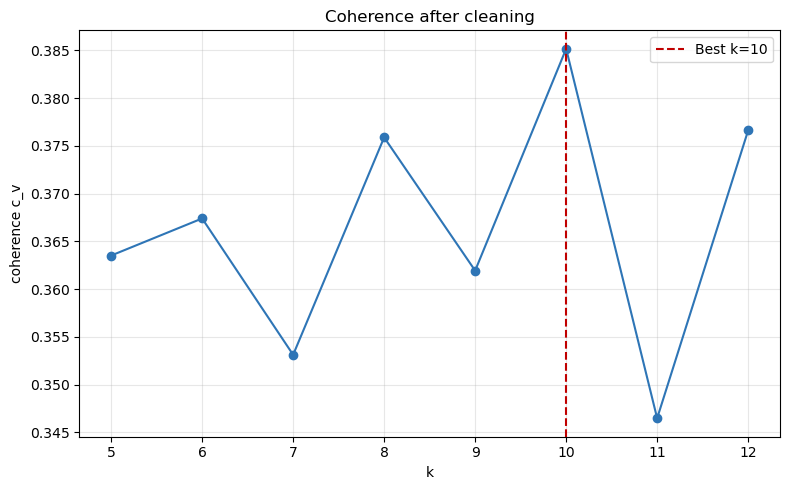

In [31]:
# ADD BIGRAMS, STRICTER FILTER, RETUNE k
# Bigrams capture "net_zero", "green_bond", "climate_risk" as single themes.

from gensim import corpora
from gensim.models import LdaModel, CoherenceModel, Phrases
from gensim.models.phrases import Phraser
import numpy as np, matplotlib.pyplot as plt

doc_keys = sorted(processed_docs.keys())
texts = [processed_docs[k] for k in doc_keys]

# Build bigrams (e.g. "net"+"zero" -> "net_zero")
phrases = Phrases(texts, min_count=5, threshold=10)
bigram = Phraser(phrases)
texts = [bigram[t] for t in texts]

dictionary = corpora.Dictionary(texts)
# stricter filtering: drop terms in <3 docs or >50% of docs (removes generic terms)
dictionary.filter_extremes(no_below=3, no_above=0.5)
bow_corpus = [dictionary.doc2bow(t) for t in texts]
print(f"Dictionary size: {len(dictionary)} terms after stricter filtering")

# Re-test k with the cleaned data
K_RANGE = range(5, 13)
coherence_scores = []
print("\nRe-testing k with cleaned corpus...\n")
for k in K_RANGE:
    m = LdaModel(corpus=bow_corpus, id2word=dictionary, num_topics=k,
                 random_state=42, passes=15, iterations=200, alpha="auto", eta="auto")
    cm = CoherenceModel(model=m, texts=texts, dictionary=dictionary, coherence="c_v")
    sc = cm.get_coherence(); coherence_scores.append(sc)
    print(f"  k={k:2d} -> c_v = {sc:.4f}")

BEST_K = list(K_RANGE)[int(np.argmax(coherence_scores))]
print(f"\n>>> BEST k = {BEST_K} (coherence {max(coherence_scores):.4f})")

plt.figure(figsize=(8,5))
plt.plot(list(K_RANGE), coherence_scores, marker="o", color="#2E75B6")
plt.axvline(BEST_K, color="#C00000", linestyle="--", label=f"Best k={BEST_K}")
plt.xlabel("k"); plt.ylabel("coherence c_v"); plt.legend(); plt.grid(alpha=0.3)
plt.title("Coherence after cleaning"); plt.tight_layout()
plt.savefig(OUT_FIGURES / "coherence_by_k.png", dpi=300); plt.show()


In [32]:
# Train final model and inspect topics

lda = LdaModel(corpus=bow_corpus, id2word=dictionary, num_topics=BEST_K,
               random_state=42, passes=25, iterations=400, alpha="auto", eta="auto")

print(f"\n===== {BEST_K} TOPICS after cleaning =====\n")
topic_rows = []
for tid in range(BEST_K):
    terms = [w for w,_ in lda.show_topic(tid, topn=15)]
    topic_rows.append({"topic": tid, "top_terms": ", ".join(terms), "label": ""})
    print(f"Topic {tid}: {', '.join(terms)}\n")

pd.DataFrame(topic_rows).to_csv(OUT_TABLES / "lda_topics.csv", index=False)
print(">>> Check these topics. They should now reflect THEMES, not bank names.")
print(">>> If still noisy, tell Claude the new topic terms and we tune further.")
print(">>> If they look thematic, assign labels and re-run Cells 11–16.")


===== 10 TOPICS after cleaning =====

Topic 0: thermal_coal, transition_zero, covid, power_utility, cybersecurity, datum_privacy, middle_east, covid_outbreak, dollar, cash_flow, nomination_corporate, mainland_china, secretary_chief, global_function, covid_pandemic

Topic 1: intensity, adaptation, supplementary_information, global_head, gcro, effectiveness_review, steel, aviation, africa_middle, residential_mortgage, east, aluminium, mobilise, thermal_coal, client_segment

Topic 2: inclusive_future, sustainable_future, transition_zero, retrofit, aviation, social_housing, affordable_housing, automotive, thermal_coal, food, farm, electric, decarbonise, economic_crime, farmer

Topic 3: metric_target, important_information, purpose_lead, rbsg, covid, adversely_affect, ethnic_minority, brexit, funding_financing, cash_flow, vulnerable_situation, cybersecurity, united_kingdom, percentage_point, cost_live

Topic 4: protect_nature, development_inclusive, building_transition, prosperous_future, 

In [33]:
# TOPIC LABELS (locked in, k=10)
TOPIC_LABELS = {
    0: "Climate Transition & Fossil-Fuel Exposure",
    1: "Sector Emissions – Heavy Industry & Aviation",
    2: "Just Transition & Affordable Housing",
    3: "Targets & Vulnerable Customers",
    4: "Nature & Community Investment",
    5: "Skills, Apprenticeships & Social Mobility",
    6: "Diversity, Equity & Inclusion",
    7: "Clean Technology & Citizenship",
    8: "Residual Reporting/Assurance Language",
    9: "Residual Financial/Legal Language",
}

# Save a labelled topics table
import pandas as pd
labelled = []
for tid in range(BEST_K):
    terms = [w for w, _ in lda.show_topic(tid, topn=15)]
    labelled.append({"topic": tid, "label": TOPIC_LABELS[tid], "top_terms": ", ".join(terms)})
labelled_df = pd.DataFrame(labelled)
labelled_df.to_csv(OUT_TABLES / "lda_topics.csv", index=False)
print("Labelled topics saved:")
print(labelled_df[["topic", "label"]].to_string(index=False))

Labelled topics saved:
 topic                                        label
     0    Climate Transition & Fossil-Fuel Exposure
     1 Sector Emissions – Heavy Industry & Aviation
     2         Just Transition & Affordable Housing
     3               Targets & Vulnerable Customers
     4                Nature & Community Investment
     5    Skills, Apprenticeships & Social Mobility
     6                Diversity, Equity & Inclusion
     7               Clean Technology & Citizenship
     8        Residual Reporting/Assurance Language
     9            Residual Financial/Legal Language
